# Alternative Credit Scoring Model – Decision Tree & Random Forest

This notebook implements Decision Tree and Random Forest models for predicting loan defaults 
in Cambodia’s unbanked population. These non-linear models can capture more complex patterns between 
alternative features and default risk compared to Logistic Regression.

In [10]:
# Import the necessary libraries for data handling, model training, evaluation, and visualization.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### Load Dataset

Load the engineered dataset (`featured_credit_risk_kh.csv`).

In [11]:
df = pd.read_csv("../data/processed/featured_credit_risk_kh.csv")
print(df.shape)
df.head()

(31650, 20)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_income_kh,loan_to_income_ratio,stability_score,interest_burden,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,land_title_type_No Title,land_title_type_Soft Title,cb_person_default_on_file_Y
0,21,9600,5.0,1000,11.14,0,0.10,2,2442.912215,0.104167,7.0,0.011604,True,False,False,False,False,False,False,False
1,25,9600,1.0,5500,12.87,1,0.57,3,2442.912215,0.572917,4.0,0.073734,False,False,True,False,False,False,False,False
2,23,65500,4.0,35000,15.23,1,0.53,2,2871.268072,0.534351,6.0,0.081382,False,False,True,False,False,False,True,False
3,24,54400,8.0,35000,14.27,1,0.55,4,2786.209932,0.643382,12.0,0.091811,False,False,True,False,False,False,True,True
4,21,9900,2.0,2500,7.14,1,0.25,2,2445.211083,0.252525,4.0,0.018030,False,False,False,False,True,False,False,False


### Split Features & Target
- Separate the dataset into features (`X`) and target (`y`). 
- The target variable `loan_status` is binary: 0 = Safe, 1 = Default.
- We split the data into training (80%) and testing (20%) sets.

In [12]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Initialize Decision Tree and Random Forest Models
- Initialize Decision Tree with default parameters.
- Initialize Random Forest with `n_estimators=100` and `random_state=42`.

In [13]:
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

### Train the Models
Train both models on the training dataset.

In [14]:
dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Make Predictions
Generate predictions on the test dataset for both models.

In [15]:
y_pred_dt = dt_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

### Evaluate Models
Evaluate the models using Accuracy, Precision, Recall, and F1-score.

Decision Tree Evaluation:
Accuracy: 0.8695102685624012
Precision: 0.7112526539278131
Recall: 0.7062543921293043
F1-score: 0.7087447108603667

Random Forest Evaluation:
Accuracy: 0.9093206951026856
Precision: 0.9283551967709385
Recall: 0.6465214335910049
F1-score: 0.7622203811101905


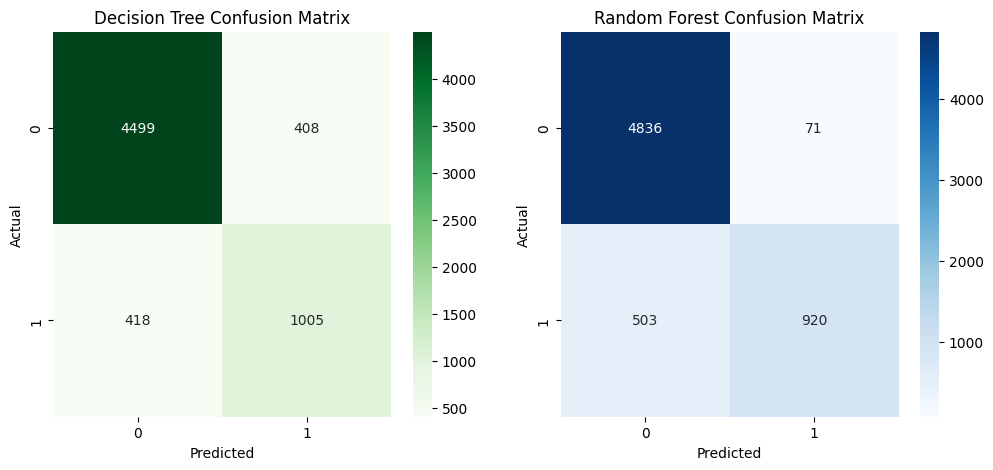

In [16]:
print("Decision Tree Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))

print("\nRandom Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=ax1)
ax1.set_title("Decision Tree Confusion Matrix")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title("Random Forest Confusion Matrix")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

# Save the plot explicitly for reference if needed
plt.savefig("../outputs/figures/confusion_matrices_dt_rf.png")
plt.show()


### Feature Importance
Decision Trees and Random Forests provide feature importance directly, showing which features are most influential.

In [17]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "DT_Importance": dt_clf.feature_importances_,
    "RF_Importance": rf_clf.feature_importances_
}).sort_values(by="RF_Importance", ascending=False)

importances


,Feature,DT_Importance,RF_Importance
4,loan_int_rate,0.194360,0.143267
8,loan_to_income_ratio,0.230861,0.140249
10,interest_burden,0.054007,0.105293
5,loan_percent_income,0.027796,0.101555
17,land_title_type_Soft Title,0.120432,0.087218
7,person_income_kh,0.076782,0.084412
1,person_income,0.056419,0.081888
3,loan_amnt,0.025277,0.044301
2,person_emp_length,0.047718,0.041137
0,person_age,0.039363,0.036337


### Save the results
Save the evaluation metrics and export the trained models.

In [18]:
with open("../outputs/reports/dt_rf_results_summary.txt", "w") as f:
    f.write("Decision Tree:\n")
    f.write(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}\n")
    f.write(f"Precision: {precision_score(y_test, y_pred_dt)}\n")
    f.write(f"Recall: {recall_score(y_test, y_pred_dt)}\n")
    f.write(f"F1-score: {f1_score(y_test, y_pred_dt)}\n\n")
    
    f.write("Random Forest:\n")
    f.write(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}\n")
    f.write(f"Precision: {precision_score(y_test, y_pred_rf)}\n")
    f.write(f"Recall: {recall_score(y_test, y_pred_rf)}\n")
    f.write(f"F1-score: {f1_score(y_test, y_pred_rf)}\n")

joblib.dump(dt_clf, "../outputs/models/decision_tree.pkl")
joblib.dump(rf_clf, "../outputs/models/random_forest.pkl")


['../outputs/models/random_forest.pkl']